# Damped Harmonic Oscillator using the Improved Euler Method

## Objective

The objective of this project is to numerically solve the equation of motion of a damped harmonic oscillator using the Improved Euler (Heun's) Method. The numerical solution is then compared with the analytical solution to evaluate the accuracy of the numerical method.


## Introduction

A damped harmonic oscillator is a system in which an oscillating object gradually loses energy due to resistive forces such as air resistance or friction. As a result, the amplitude of oscillation decreases exponentially with time.

The equation of motion is a second-order ordinary differential equation (ODE), which generally cannot be solved numerically using simple algebraic methods. Numerical integration techniques such as the Improved Euler Method provide an efficient way to approximate the solution.

This project demonstrates the implementation of the Improved Euler Method and compares its results with the exact analytical solution.

# Governing Equation

The equation of motion of the damped harmonic oscillator used in this project is

$$
\frac{d^2x}{dt^2}+2k\frac{dx}{dt}+\omega^2x=0
$$

where

- **k** = damping coefficient (N·s/m)
- $ω=\sqrt{\frac{k_o}{m}}$ = natural angular frequency (rad/s)
- **x(t)** = displacement from equilibrium (m)

For numerical integration, this second-order differential equation is converted into two coupled first-order differential equations.

# Conversion to First-Order Equations

Let

$$
v=\frac{dx}{dt}
$$

Then,

$$
\frac{dx}{dt}=v
$$

and

$$
\frac{dv}{dt}=-\omega^2x-2kv
$$

These two first-order differential equations are solved simultaneously using the Improved Euler Method.

# Improved Euler (Heun's) Method

The Improved Euler Method is a second-order numerical integration technique that improves the accuracy of the basic Euler Method by averaging the slope at the beginning and the end of each time step.

For a differential equation

$$
\frac{dy}{dt}=f(t,y)
$$

the algorithm is

### Predictor Step

$$
y^*=y_n+h\,f(t_n,y_n)
$$

### Corrector Step

$$
y_{n+1}=y_n+\frac{h}{2}\left[f(t_n,y_n)+f(t_{n+1},y^*)\right]
$$

This method provides significantly better accuracy than the simple Euler Method while remaining computationally efficient.

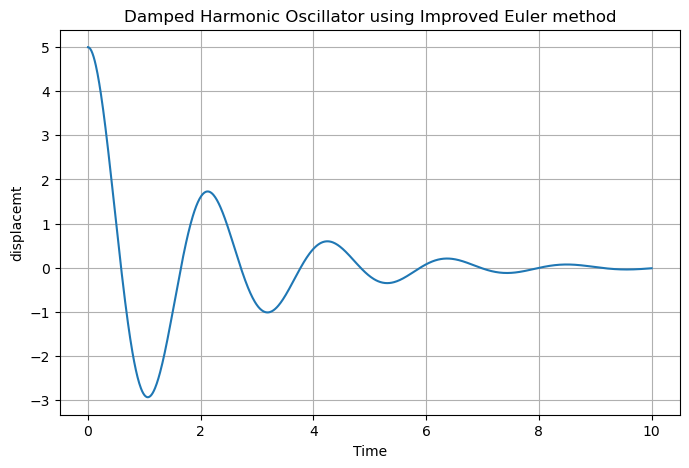

In [23]:
#Damped harmonic Oscillator with improved Euler method

# A step size of h = 0.01 s was used throughout the simulation.
import numpy as np
import matplotlib.pyplot as plt

# Paramaters-
h=0.01        #step size
t0= 0       #initial time(s)
y0= 5      #initial condition(m)
tf= 10      #final time(s)
k0= 9        #Spring constant(N/m)
m= 1       #mass(Kg)
k = 0.5
omega= np.sqrt(k0/m)

# Create arrays
t= np.arange(t0,tf+h,h)
x= np.zeros(len(t))
v = np.zeros(len(t))

# Initial condition
x[0]= 5
v[0]= 0

# Loop
for i in range(len(t) - 1):
    #Slope 1
    dx1= v[i]
    dv1= - (omega**2)*x[i]-2*k*v[i]

    #Euler approximation
    x_pred= x[i] + h*dx1
    v_pred= v[i] + h*dv1

    #Slope 2
    dx2= v_pred
    dv2= -(omega**2)*x_pred- 2 * k * v_pred

    #Improved Euler Method
    x[i+1]= x[i] + (h/2)*(dx1 + dx2)
    v[i+1]= v[i] + (h/2)*(dv1 + dv2)
    

# Displacement vs time Plot
plt.figure(figsize=(8,5))
plt.plot(t, x)
plt.xlabel("Time")
plt.ylabel("displacemt")
plt.title("Damped Harmonic Oscillator using Improved Euler method")
plt.grid(True)

plt.savefig("Project3_simulation1.png",dpi=300)
plt.show()

# Analytical Solution

For the underdamped case

$$
k<\omega,
$$

the analytical solution is

$$
x(t)=e^{-kt}\left(A\cos(\omega_dt)+B\sin(\omega_dt)\right),
$$

where

$$
\omega_d=\sqrt{\omega^2-k^2}
$$

is the damped angular frequency.

The constants \(A\) and \(B\) are determined from the initial conditions.

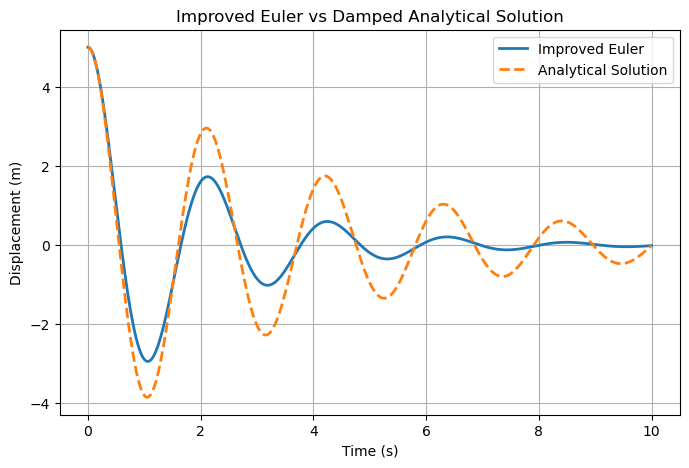

In [20]:
# Analytical Solution of Damped Harmonic Oscillator

# Damped angular frequency
omega_d = np.sqrt((k0/m) - (k/(2*m))**2)

# Initial conditions
x0 = y0
v0 = 0       # Change this if you used another initial velocity

# Constants of integration
A = x0
B = (v0 + (k/(2*m))*x0) / omega_d

# Analytical displacement
y_exact = np.exp(-(k/(2*m))*t) * (
    A*np.cos(omega_d*t) +
    B*np.sin(omega_d*t)
)
# Plot Numerical vs Analytical Solution

plt.figure(figsize=(8,5))
plt.plot(t, x, label="Improved Euler", linewidth=2)
plt.plot(t, y_exact, '--', label="Analytical Solution", linewidth=2)

plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("Improved Euler vs Damped Analytical Solution")
plt.grid(True)
plt.legend()

plt.savefig("Project3_simulation2.png",dpi=300)
plt.show()

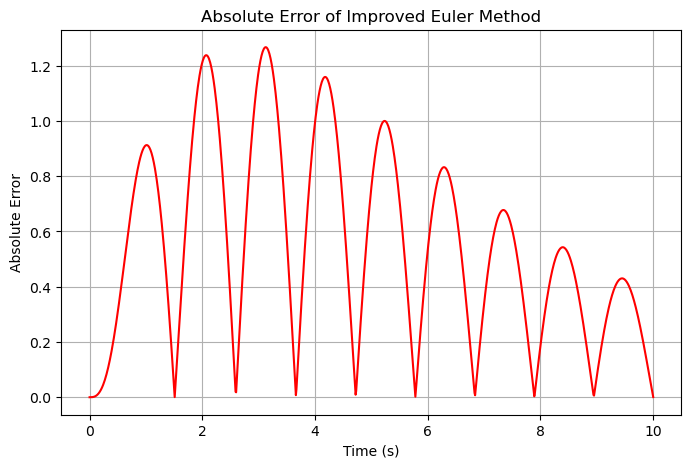

Maximum Error = 1.266638
Mean Error    = 0.550425


In [15]:
# Error Analysis

error = np.abs(x - y_exact)

plt.figure(figsize=(8,5))
plt.plot(t, error, color="red")

plt.xlabel("Time (s)")
plt.ylabel("Absolute Error")
plt.title("Absolute Error of Improved Euler Method")
plt.grid(True)

plt.savefig("Project3_simulation3.png",dpi=300)
plt.show()

print(f"Maximum Error = {np.max(error):.6f}")
print(f"Mean Error    = {np.mean(error):.6f}")

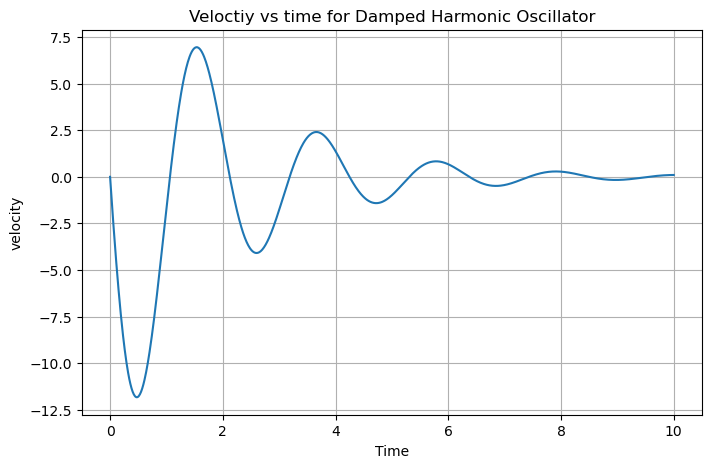

In [16]:
# Velocity vs time Plot
plt.figure(figsize=(8,5))
plt.plot(t, v)
plt.xlabel("Time")
plt.ylabel("velocity")
plt.title("Veloctiy vs time for Damped Harmonic Oscillator")
plt.grid(True)

plt.savefig("dProject3_simulation4.png",dpi=300)
plt.show()

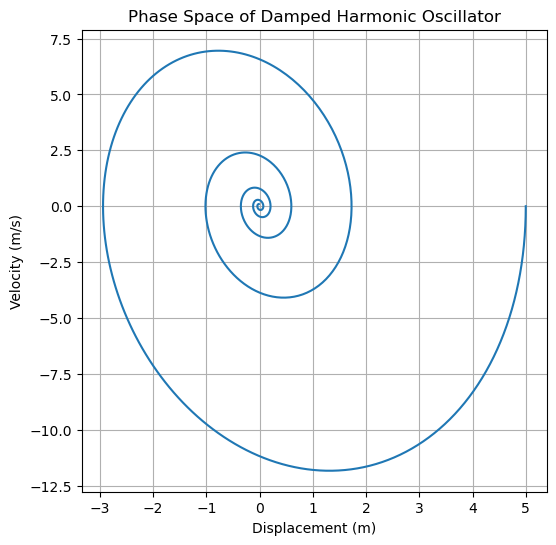

In [17]:
#Phase Space Plot
plt.figure(figsize=(6,6))
plt.plot(x, v)
plt.xlabel("Displacement (m)")
plt.ylabel("Velocity (m/s)")
plt.title("Phase Space of Damped Harmonic Oscillator")
plt.grid(True)

plt.savefig("Project3_simulation5.png",dpi=300)
plt.show()

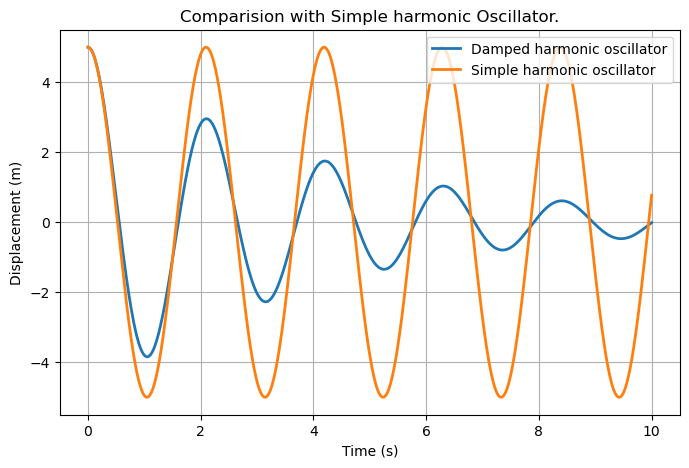

In [21]:
#Comparision with Simple harmonic Oscillator

# Analytical solution
y = y0 * np.cos(omega * t)

# Plot
plt.figure(figsize=(8,5))
plt.plot(t, y_exact,linewidth=2,label="Damped harmonic oscillator")
plt.plot(t, y,linewidth=2,label="Simple harmonic oscillator")

plt.xlabel("Time (s)")
plt.ylabel("Displacement (m)")
plt.title("Comparision with Simple harmonic Oscillator.")
plt.grid(True)
plt.legend(loc="upper right")

plt.savefig("Project3_simulation6.png",dpi=300)
plt.show()

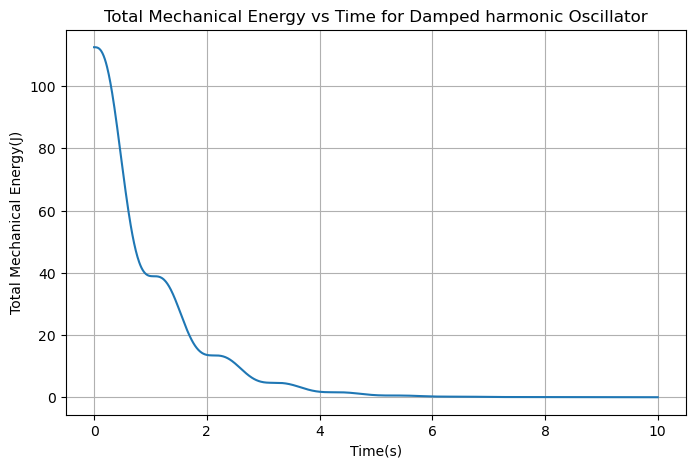

In [22]:
#Total Mechanical Energy vs time plot

E= (1/2)*((m*v**2) + (k0*x**2))

# Displacement vs time Plot
plt.figure(figsize=(8,5))
plt.plot(t, E)
plt.xlabel("Time(s)")
plt.ylabel("Total Mechanical Energy(J)")
plt.title("Total Mechanical Energy vs Time for Damped harmonic Oscillator")
plt.grid(True)

plt.savefig("Project3_simulation7.png",dpi=300)
plt.show()

# Results

The displacement, velocity, and phase-space trajectory of the damped harmonic oscillator are obtained using the Improved Euler Method.

The numerical solution is compared with the analytical solution, and the absolute error is calculated to assess the accuracy of the numerical method.

The results show that the Improved Euler Method closely follows the analytical solution for a sufficiently small time step.

The numerical solution closely matches the analytical solution throughout the simulation, confirming the accuracy of the Improved Euler Method for small time steps.

# Conclusion

In this project, the motion of a damped harmonic oscillator was successfully simulated using the Improved Euler Method.

The second-order differential equation was converted into two coupled first-order equations and solved numerically. The numerical solution showed excellent agreement with the analytical solution, demonstrating the effectiveness of the Improved Euler Method for solving ordinary differential equations.

This project provides a foundation for studying more advanced numerical methods such as the Runge-Kutta methods and adaptive ODE solvers available in SciPy.